# **Knowledge distillation**

Compress the continual-learning model into a small student and compare four ways of
training it. The teacher is the replay + LwF ResNet50; the student is a
MobileNetV3-Small + LSTM. Both are trained and tested on the full 20-class set.

- **CE**: the student alone, no teacher (the baseline).
- **CE + KD**: CE plus KL between the student's and teacher's softened logits.
- **CE + Cosine**, CE plus cosine distance between the two 256-d LSTM states.
- **CE + MSE**, CE plus MSE between the two 256-d LSTM states.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess data**

Group-disjoint clips for all three tasks

In [5]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [6]:
# To show the effect of knowledge distillation, we will train a student model with a limited number of samples per class.   
# We will use the `max_samples` variable to control the number of samples per class for training the student model.
max_samples = 32

In [7]:
# BASE (max_samples caps TRAIN clips/class; None = full data, val/test untouched)
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=max_samples)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: 32

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [8]:
# TASK 1 (same TRAIN-only cap via cfg.MAX_SAMPLES)
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT, max_samples=max_samples)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5 | Train limit: 32

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


In [9]:
# TASK 2 (same TRAIN-only cap via cfg.MAX_SAMPLES)
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT, max_samples=max_samples)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5 | Train limit: 32

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


In [10]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(f"{len(ALL_CLASSES_LIST)} classes")
print(class_to_idx)

20 classes
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


## **Create Loaders**

The student is trained on all 20 classes at once, so the three tasks are concatenated into one train / val / test set.

In [11]:
base_train  = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "train"), class_to_idx=class_to_idx)
base_val    = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "val"),   class_to_idx=class_to_idx)
base_test   = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx)
task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

train_loader = DataLoader(ConcatDataset([base_train, task1_train, task2_train]), batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(ConcatDataset([base_val,   task1_val,   task2_val]),   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(ConcatDataset([base_test,  task1_test,  task2_test]),  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train {len(train_loader.dataset)}  val {len(val_loader.dataset)}  test {len(test_loader.dataset)}")

train 640  val 323  test 439


## **Upload Model**

Load the replay + LwF teacher and check its test accuracy

In [12]:
teacher = ResNet50LSTM(num_classes=len(ALL_CLASSES_LIST)).to(device)
teacher.load_state_dict(torch.load(f"{cfg.CKPT_DIR}/replay_lwf.pt", map_location=device))
teacher.eval()

ResNet50LSTM(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [13]:
teacher_acc, _, _ = test_model(teacher, test_loader, device)
print(f"teacher test accuracy: {teacher_acc:.4f}")
RESULTS = []

Test Accuracy: 0.8679
teacher test accuracy: 0.8679


## **CE (no teacher)**

In [14]:
student_ce = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

In [15]:
set_seed(cfg.SEED)
student_ce, hist_student_ce = train_student(student_ce, None, train_loader, val_loader, device,
                                  mode="ce", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[         ce] epoch 01/15 | Train Acc: 0.1828 | Val Acc: 0.3839
[         ce] epoch 02/15 | Train Acc: 0.5094 | Val Acc: 0.5635
[         ce] epoch 03/15 | Train Acc: 0.7125 | Val Acc: 0.5944
[         ce] epoch 04/15 | Train Acc: 0.8313 | Val Acc: 0.6223
[         ce] epoch 05/15 | Train Acc: 0.8797 | Val Acc: 0.6347
[         ce] epoch 06/15 | Train Acc: 0.8984 | Val Acc: 0.6656
[         ce] epoch 07/15 | Train Acc: 0.9406 | Val Acc: 0.6997
[         ce] epoch 08/15 | Train Acc: 0.9641 | Val Acc: 0.6718
[         ce] epoch 09/15 | Train Acc: 0.9578 | Val Acc: 0.6471
[         ce] epoch 10/15 | Train Acc: 0.9672 | Val Acc: 0.6749
[         ce] epoch 11/15 | Train Acc: 0.9781 | Val Acc: 0.6842
[         ce] epoch 12/15 | Train Acc: 0.9828 | Val Acc: 0.6099
[         ce] epoch 13/15 | Train Acc: 0.9812 | Val Acc: 0.6471
[         ce] epoch 14/15 | Train Acc: 0.9734 | Val Acc: 0.6254
[         ce] epoch 15/15 | Train Acc: 0.9844 | Val Acc: 0.6285
  best [ce] val 0.6997


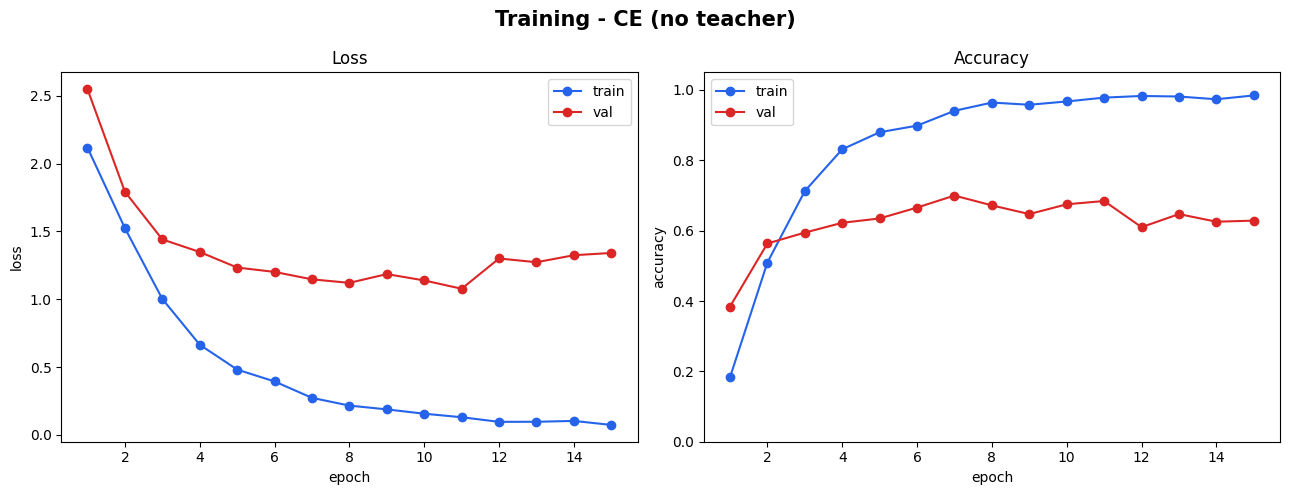

In [16]:
plot_training_results(hist_student_ce, task_name="CE (no teacher)")

In [17]:
acc_student_ce, preds_student_ce, labels_student_ce = test_model(student_ce, test_loader, device)

  test:   0%|          | 0/110 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
                                                         

Test Accuracy: 0.6150


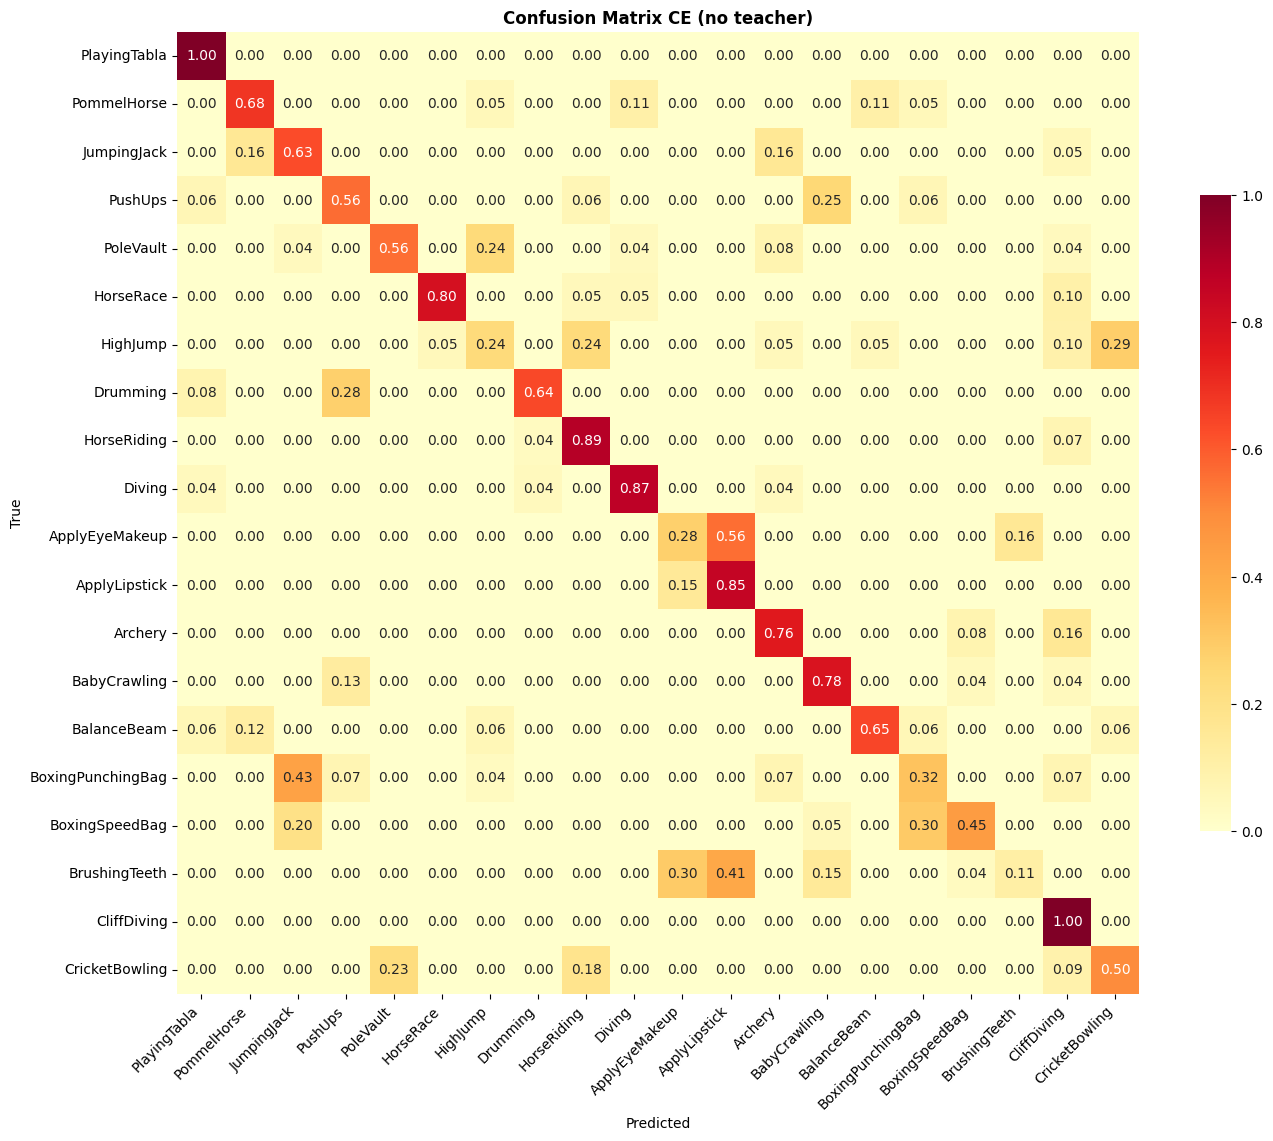

In [18]:
plot_confusion_matrix(labels_student_ce, preds_student_ce, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE (no teacher)")

In [19]:
params_student_ce = sum(p.numel() for p in student_ce.parameters())
RESULTS.append({"mode": "CE (no teacher)", "test_acc": acc_student_ce, "params_M": params_student_ce / 1e6})

## **CE + KD**

In [20]:
student_kd = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

In [21]:
set_seed(cfg.SEED)
student_kd, hist_student_kd = train_student(student_kd, teacher, train_loader, val_loader, device,
                                  mode="kd", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[         kd] epoch 01/15 | Train Acc: 0.1953 | Val Acc: 0.3715
[         kd] epoch 02/15 | Train Acc: 0.4953 | Val Acc: 0.5325
[         kd] epoch 03/15 | Train Acc: 0.7031 | Val Acc: 0.5480
[         kd] epoch 04/15 | Train Acc: 0.8172 | Val Acc: 0.6192
[         kd] epoch 05/15 | Train Acc: 0.8969 | Val Acc: 0.6471
[         kd] epoch 06/15 | Train Acc: 0.8750 | Val Acc: 0.6594
[         kd] epoch 07/15 | Train Acc: 0.9375 | Val Acc: 0.6440
[         kd] epoch 08/15 | Train Acc: 0.9453 | Val Acc: 0.6223
[         kd] epoch 09/15 | Train Acc: 0.9516 | Val Acc: 0.6006
[         kd] epoch 10/15 | Train Acc: 0.9578 | Val Acc: 0.6471
[         kd] epoch 11/15 | Train Acc: 0.9656 | Val Acc: 0.6285
[         kd] epoch 12/15 | Train Acc: 0.9719 | Val Acc: 0.5789
[         kd] epoch 13/15 | Train Acc: 0.9719 | Val Acc: 0.6440
[         kd] epoch 14/15 | Train Acc: 0.9812 | Val Acc: 0.6409
[         kd] epoch 15/15 | Train Acc: 0.9812 | Val Acc: 0.6254
  best [kd] val 0.6594


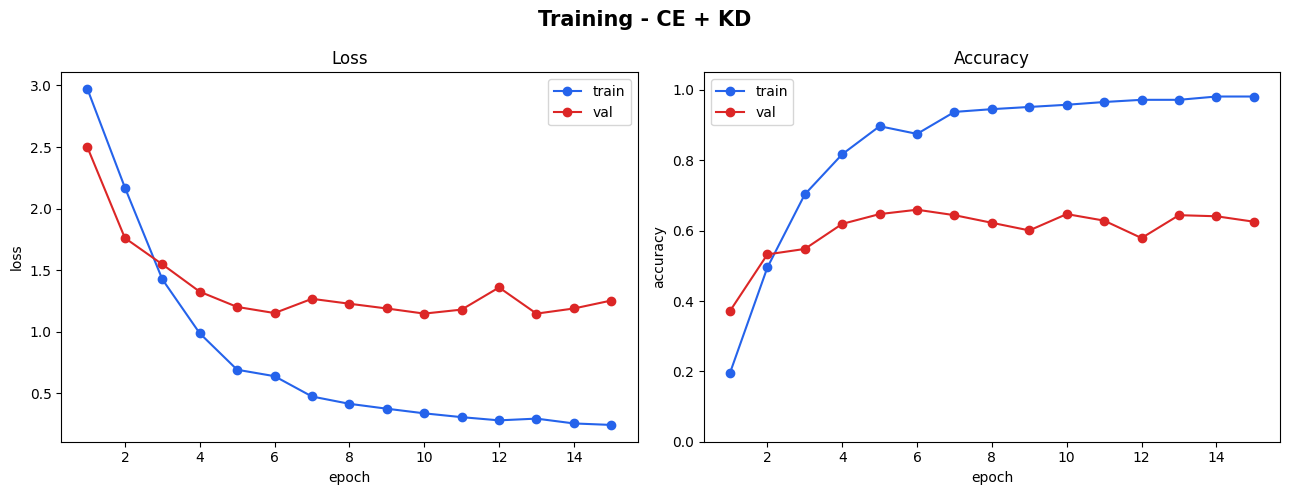

In [22]:
plot_training_results(hist_student_kd, task_name="CE + KD")

In [23]:
acc_student_kd, preds_student_kd, labels_student_kd = test_model(student_kd, test_loader, device)

  test:   0%|          | 0/110 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
                                                         

Test Accuracy: 0.6196


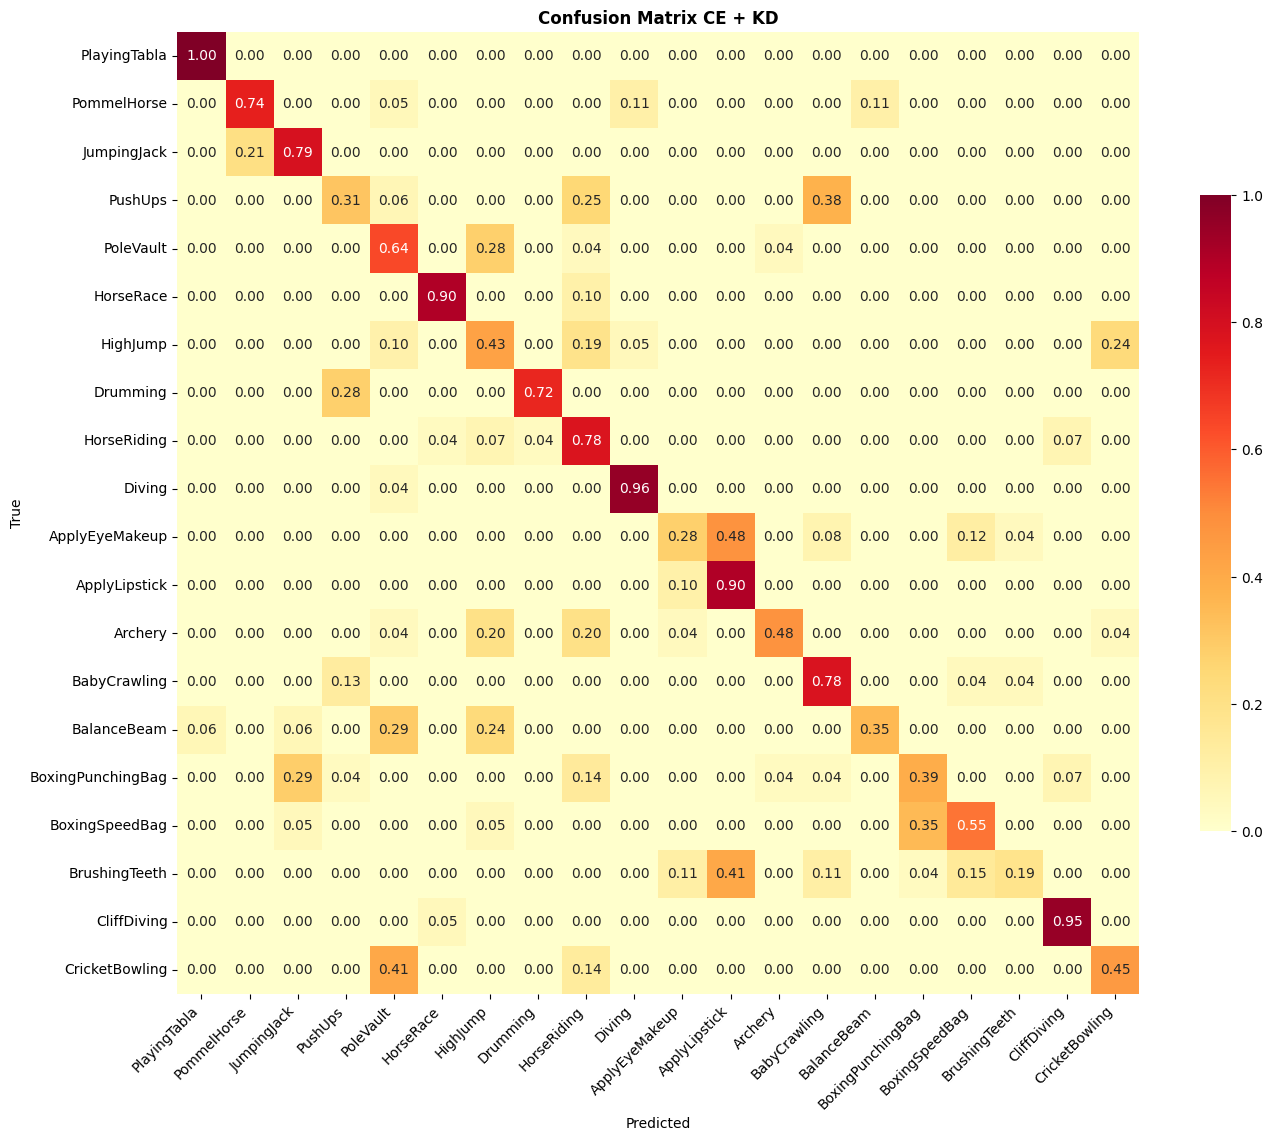

In [24]:
plot_confusion_matrix(labels_student_kd, preds_student_kd, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + KD")

In [25]:
params_student_kd = sum(p.numel() for p in student_kd.parameters())
RESULTS.append({"mode": "CE + KD", "test_acc": acc_student_kd, "params_M": params_student_kd / 1e6})

## **CE + Cosine**

In [26]:
student_cos = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

In [27]:
set_seed(cfg.SEED)
student_cos, hist_student_cos = train_student(student_cos, teacher, train_loader, val_loader, device,
                                  mode="cosine", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[     cosine] epoch 01/15 | Train Acc: 0.1906 | Val Acc: 0.3003
[     cosine] epoch 02/15 | Train Acc: 0.5031 | Val Acc: 0.5325
[     cosine] epoch 03/15 | Train Acc: 0.7156 | Val Acc: 0.5820
[     cosine] epoch 04/15 | Train Acc: 0.8375 | Val Acc: 0.5759
[     cosine] epoch 05/15 | Train Acc: 0.9078 | Val Acc: 0.6316
[     cosine] epoch 06/15 | Train Acc: 0.9156 | Val Acc: 0.6563
[     cosine] epoch 07/15 | Train Acc: 0.9375 | Val Acc: 0.5851
[     cosine] epoch 08/15 | Train Acc: 0.9422 | Val Acc: 0.6006
[     cosine] epoch 09/15 | Train Acc: 0.9547 | Val Acc: 0.5851
[     cosine] epoch 10/15 | Train Acc: 0.9719 | Val Acc: 0.6068
[     cosine] epoch 11/15 | Train Acc: 0.9703 | Val Acc: 0.6316
[     cosine] epoch 12/15 | Train Acc: 0.9688 | Val Acc: 0.5356
[     cosine] epoch 13/15 | Train Acc: 0.9656 | Val Acc: 0.6130
[     cosine] epoch 14/15 | Train Acc: 0.9844 | Val Acc: 0.6254
[     cosine] epoch 15/15 | Train Acc: 0.9828 | Val Acc: 0.6347
  best [cosine] val 0.6563


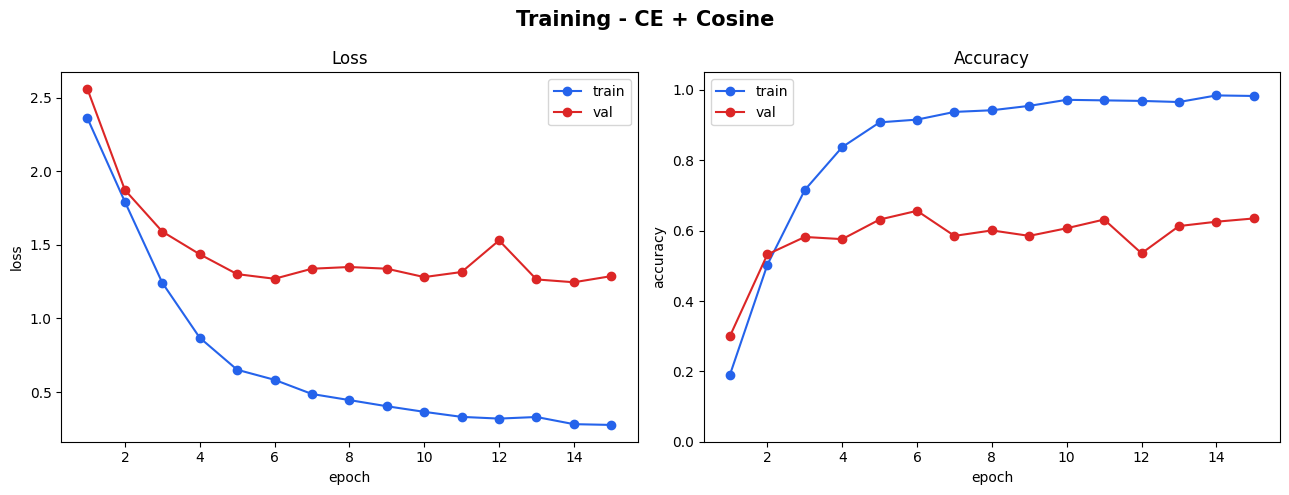

In [28]:
plot_training_results(hist_student_cos, task_name="CE + Cosine")

In [29]:
acc_student_cos, preds_student_cos, labels_student_cos = test_model(student_cos, test_loader, device)

  test:   0%|          | 0/110 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
                                                         

Test Accuracy: 0.5968


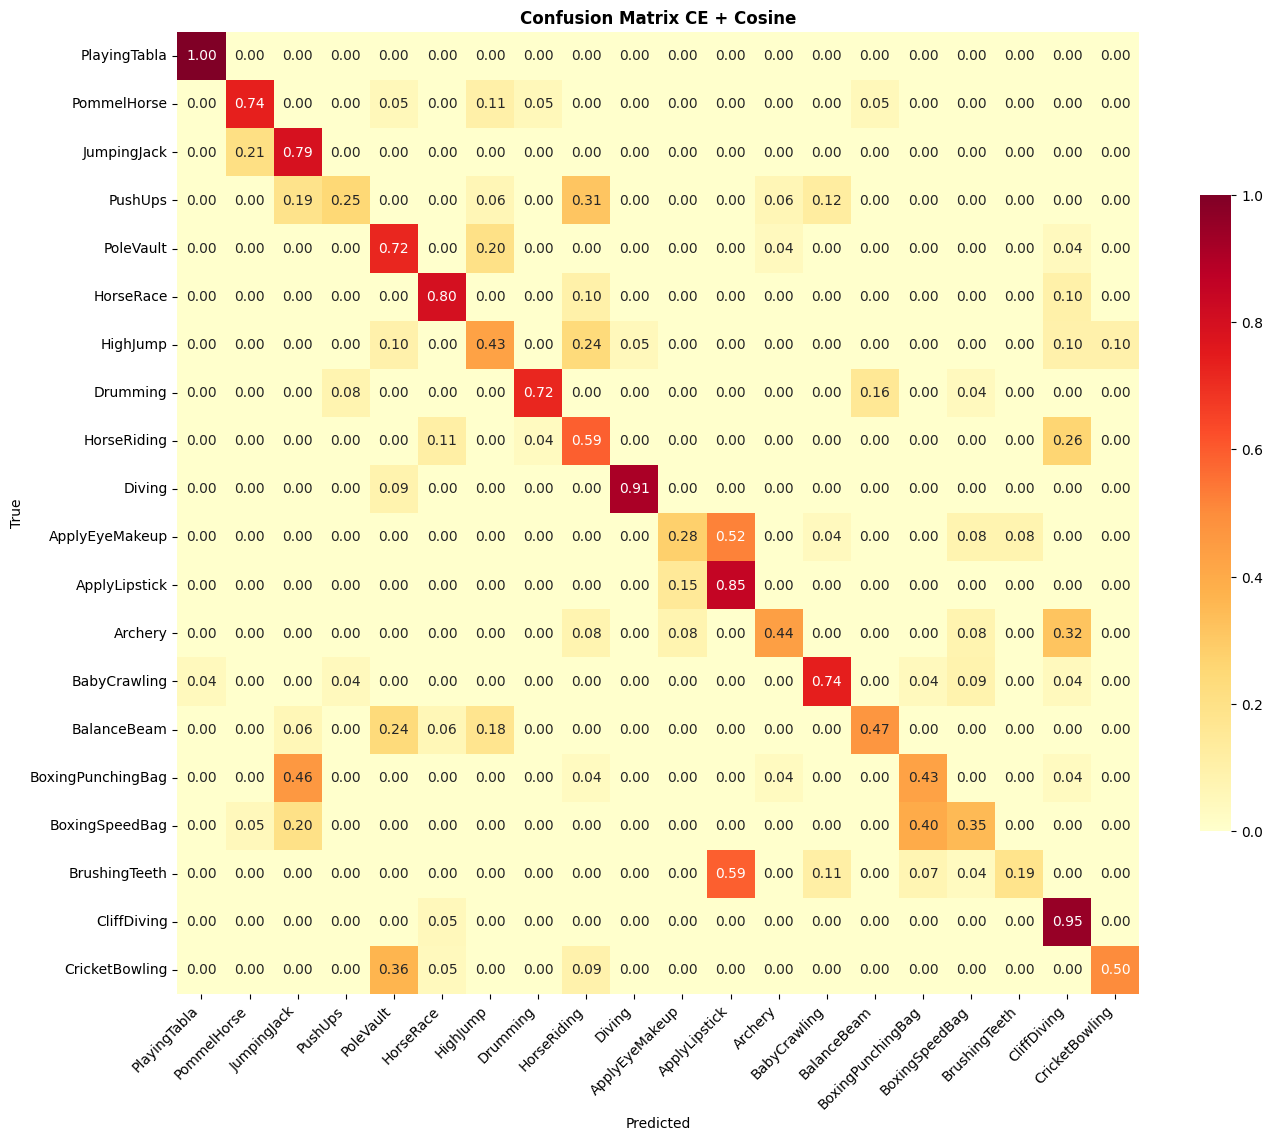

In [30]:
plot_confusion_matrix(labels_student_cos, preds_student_cos, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + Cosine")

In [31]:
params_student_cos = sum(p.numel() for p in student_cos.parameters())
RESULTS.append({"mode": "CE + Cosine", "test_acc": acc_student_cos, "params_M": params_student_cos / 1e6})

## **CE + MSE (regressor)**

In [32]:
student_mse = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

In [33]:
set_seed(cfg.SEED)
student_mse, hist_student_mse = train_student(student_mse, teacher, train_loader, val_loader, device,
                                  mode="mse", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                  distill_weight=cfg.KD_DISTILL_WEIGHT,
                                  epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)

[        mse] epoch 01/15 | Train Acc: 0.1688 | Val Acc: 0.3498
[        mse] epoch 02/15 | Train Acc: 0.5312 | Val Acc: 0.5015
[        mse] epoch 03/15 | Train Acc: 0.7547 | Val Acc: 0.5789
[        mse] epoch 04/15 | Train Acc: 0.8359 | Val Acc: 0.5913
[        mse] epoch 05/15 | Train Acc: 0.8844 | Val Acc: 0.5635
[        mse] epoch 06/15 | Train Acc: 0.9141 | Val Acc: 0.6347
[        mse] epoch 07/15 | Train Acc: 0.9563 | Val Acc: 0.6068
[        mse] epoch 08/15 | Train Acc: 0.9578 | Val Acc: 0.6192
[        mse] epoch 09/15 | Train Acc: 0.9563 | Val Acc: 0.6068
[        mse] epoch 10/15 | Train Acc: 0.9578 | Val Acc: 0.5851
[        mse] epoch 11/15 | Train Acc: 0.9938 | Val Acc: 0.5789
[        mse] epoch 12/15 | Train Acc: 0.9766 | Val Acc: 0.6254
[        mse] epoch 13/15 | Train Acc: 0.9844 | Val Acc: 0.6347
[        mse] epoch 14/15 | Train Acc: 0.9672 | Val Acc: 0.6130
[        mse] epoch 15/15 | Train Acc: 0.9828 | Val Acc: 0.6409
  best [mse] val 0.6409


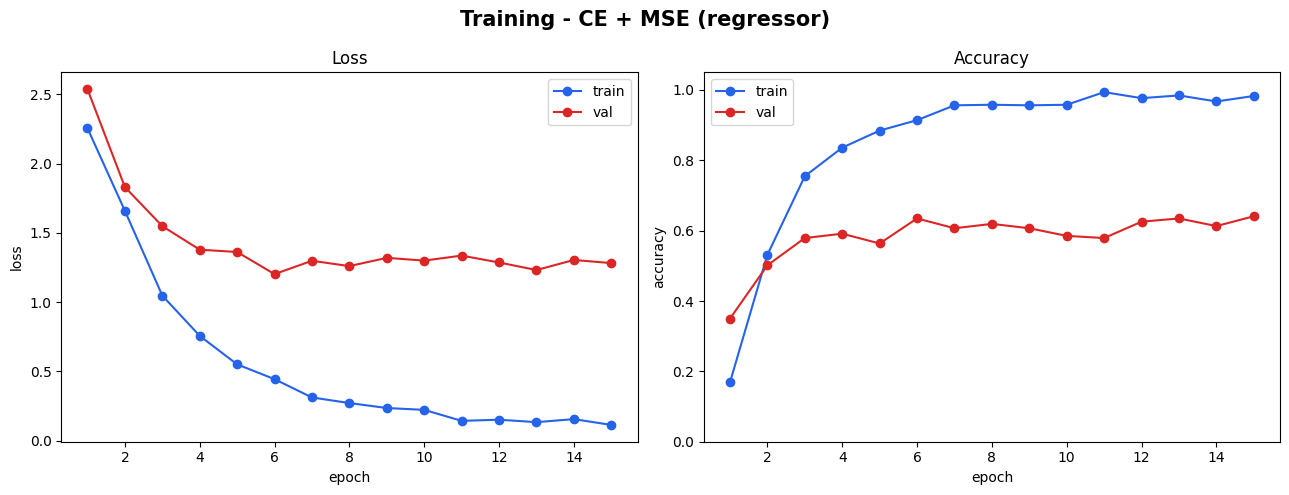

In [34]:
plot_training_results(hist_student_mse, task_name="CE + MSE (regressor)")

In [35]:
acc_student_mse, preds_student_mse, labels_student_mse = test_model(student_mse, test_loader, device)

  test:   0%|          | 0/110 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
                                                         

Test Accuracy: 0.6128


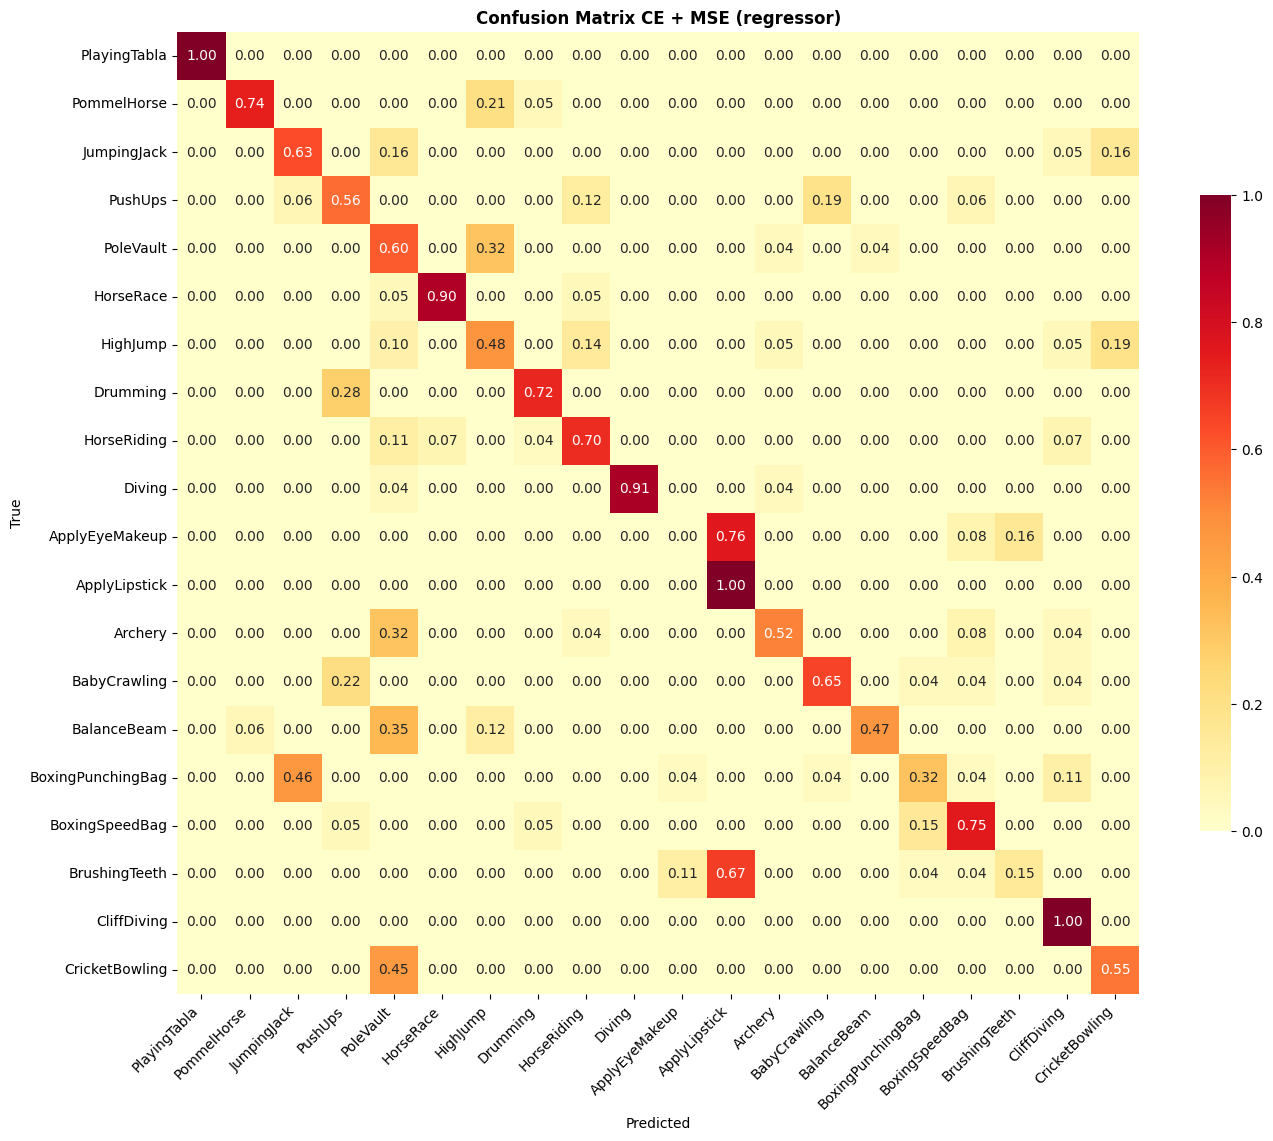

In [36]:
plot_confusion_matrix(labels_student_mse, preds_student_mse, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + MSE (regressor)")

In [37]:
params_student_mse = sum(p.numel() for p in student_mse.parameters())
RESULTS.append({"mode": "CE + MSE (regressor)", "test_acc": acc_student_mse, "params_M": params_student_mse / 1e6})

## **Class-Prototypes Alignment**

In [40]:
student_proto = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)

In [41]:
set_seed(cfg.SEED)
student_proto, hist_student_proto = train_student(
    student_proto, 
    teacher, 
    train_loader, 
    val_loader, 
    device,
    mode="proto_align", 
    T=cfg.KD_T, 
    ce_weight=cfg.KD_CE_WEIGHT,
    distill_weight=cfg.KD_DISTILL_WEIGHT,
    proto_weight=0.5,       
    n_clusters=3,           # Number of KMeans clusters per class
    seed=cfg.SEED,          # Ensures reproducible KMeans clustering
    epochs=cfg.KD_EPOCHS, 
    lr=cfg.KD_LR
)

[proto_align] Extracting teacher feature prototypes using KMeans...
[proto_align] epoch 01/15 | Train Acc: 0.1953 | Val Acc: 0.3684
[proto_align] epoch 02/15 | Train Acc: 0.5266 | Val Acc: 0.5573
[proto_align] epoch 03/15 | Train Acc: 0.6984 | Val Acc: 0.6223
[proto_align] epoch 04/15 | Train Acc: 0.8187 | Val Acc: 0.5913
[proto_align] epoch 05/15 | Train Acc: 0.8969 | Val Acc: 0.6842
[proto_align] epoch 06/15 | Train Acc: 0.9281 | Val Acc: 0.6347
[proto_align] epoch 07/15 | Train Acc: 0.9219 | Val Acc: 0.6966
[proto_align] epoch 08/15 | Train Acc: 0.9578 | Val Acc: 0.6316
[proto_align] epoch 09/15 | Train Acc: 0.9547 | Val Acc: 0.6687
[proto_align] epoch 10/15 | Train Acc: 0.9563 | Val Acc: 0.6656
[proto_align] epoch 11/15 | Train Acc: 0.9750 | Val Acc: 0.6935
[proto_align] epoch 12/15 | Train Acc: 0.9766 | Val Acc: 0.7307
[proto_align] epoch 13/15 | Train Acc: 0.9781 | Val Acc: 0.6873
[proto_align] epoch 14/15 | Train Acc: 0.9891 | Val Acc: 0.6347
[proto_align] epoch 15/15 | Train Ac

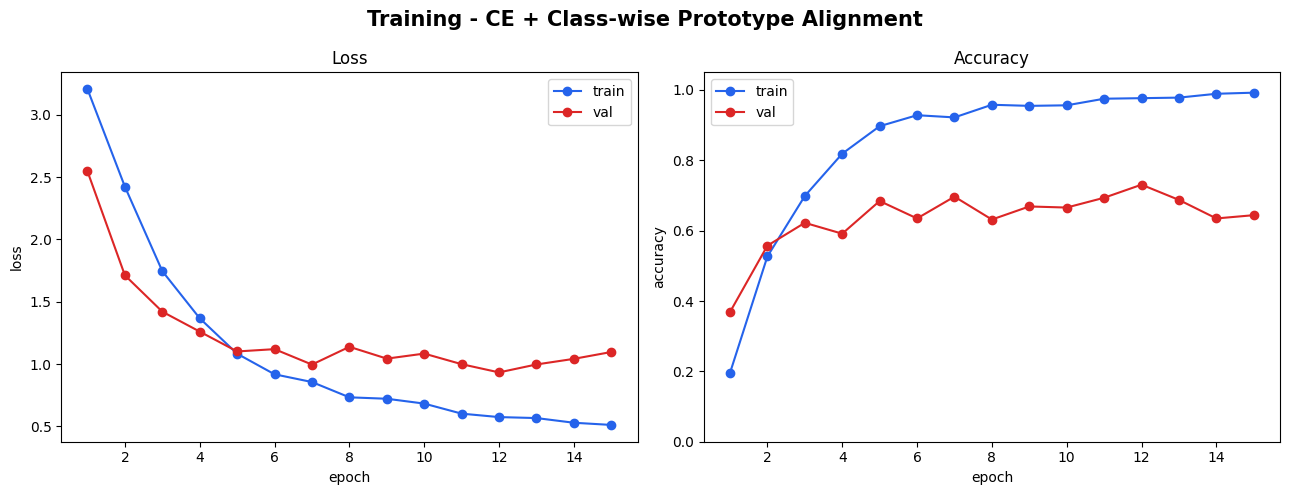

In [42]:
plot_training_results(hist_student_proto, task_name="CE + Class-wise Prototype Alignment")

In [43]:
acc_student_proto, preds_student_proto, labels_student_proto = test_model(student_proto, test_loader, device)

  test:   0%|          | 0/110 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(
                                                         

Test Accuracy: 0.6788


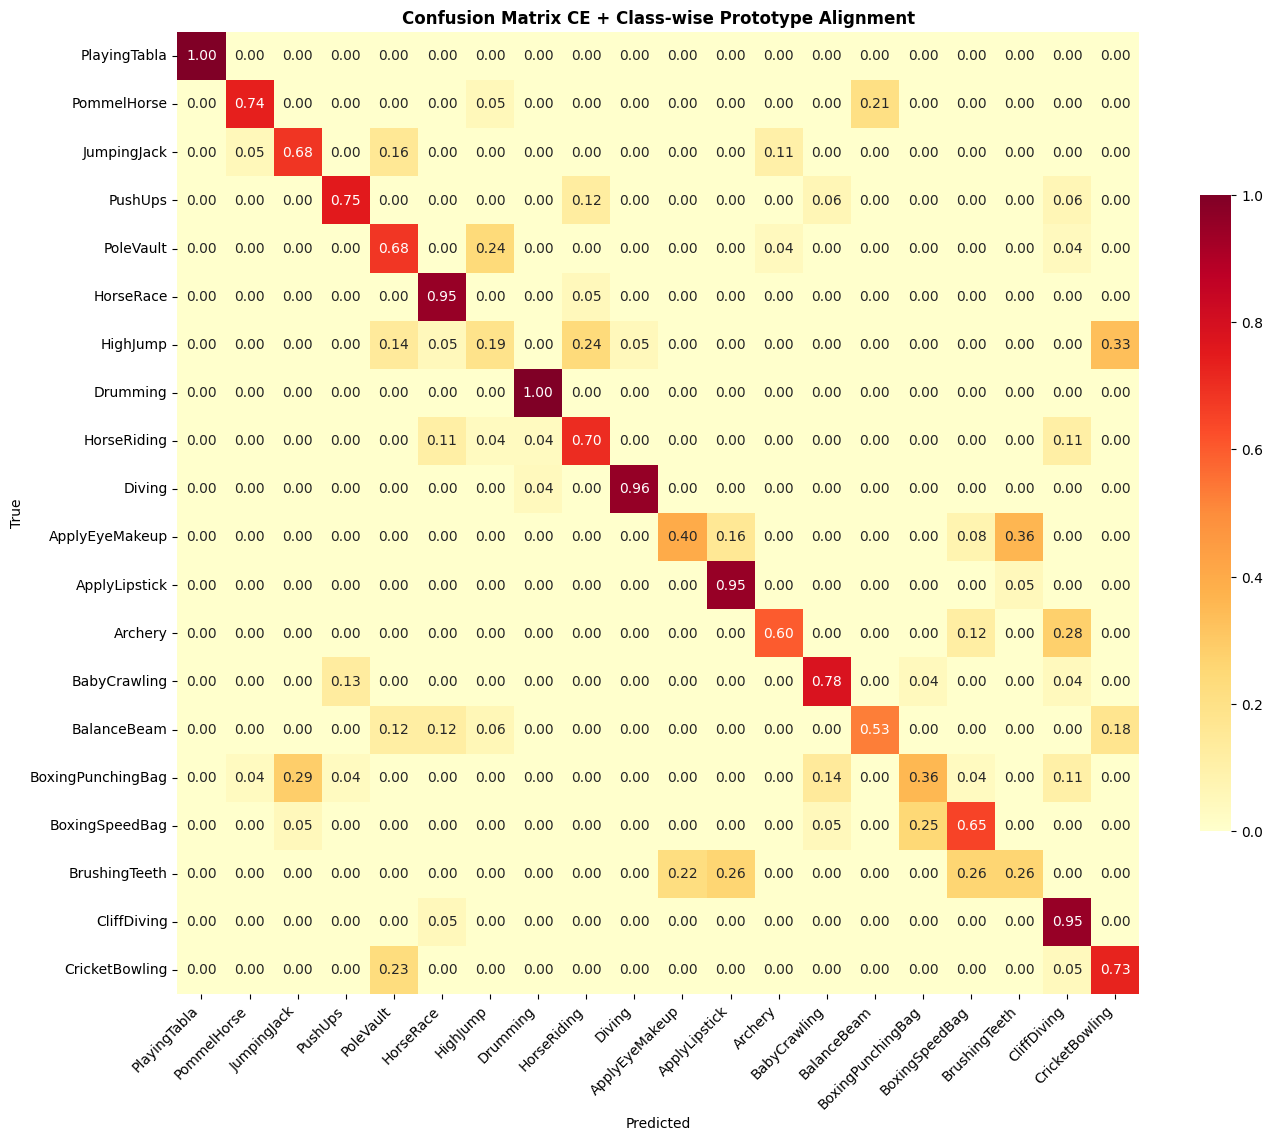

In [44]:
plot_confusion_matrix(labels_student_proto, preds_student_proto, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="CE + Class-wise Prototype Alignment")

In [45]:
params_student_proto = sum(p.numel() for p in student_proto.parameters())
RESULTS.append({"mode": "CE + Class-wise Prototype Alignment", "test_acc": acc_student_proto, "params_M": params_student_proto / 1e6})

## **Compare**

In [46]:
teacher_params = sum(p.numel() for p in teacher.parameters())
print(f"teacher : {teacher_acc:.4f}   ({teacher_params/1e6:.1f}M params)")
print(f"student is about {teacher_params / (RESULTS[0]['params_M'] * 1e6):.0f}x smaller than the teacher")

teacher : 0.8679   (25.9M params)
student is about 14x smaller than the teacher


In [47]:
results_df = pd.DataFrame(RESULTS).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df

,mode,test_acc,params_M
0,CE + Class-wise Prototype Alignment,0.678815,1.786164
1,CE + KD,0.619590,1.786164
2,CE (no teacher),0.615034,1.786164
3,CE + MSE (regressor),0.612756,1.786164
4,CE + Cosine,0.596811,1.786164


## **Save**

The CE + KD student is saved as the student used in the domain-adaptation stage.

In [48]:
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
torch.save(student_proto.state_dict(), f"{cfg.CKPT_DIR}/student_proto.pt")
print(f"saved student -> {cfg.CKPT_DIR}/student_proto.pt")

saved student -> /content/drive/MyDrive/apai/checkpoints/student_proto.pt


In [49]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"teacher_acc": teacher_acc, "teacher_params": teacher_params, "students": RESULTS}
with open(f"{cfg.RESULTS_DIR}/stage4_student_proto_distillation.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage4_student_proto_distillation.json")

saved -> /content/drive/MyDrive/apai/results/stage4_student_proto_distillation.json
